# ATES-metal: effect of trace-metal cooling (MINPACK metals)

Same comparison as `ATES_extended/metals_comparison.ipynb`, but here the
metals (C, N, O) are solved **inside the MINPACK 9-equation ionization
system** and the metal ion densities are written as extra columns of
`Ion_species.txt` (no separate Metals file).

Generate the two result sets with:
```bash
./run_compare_metals.sh    # rebuilds with X_C/X_N/X_O on, then off
```

Column layout:
* `Hydro_ioniz.txt`  : r, rho, v, p, T, heating, cooling
* `Ion_species.txt`  : r, nHI, nHII, nHeI, nHeII, nHeIII, nHeITR,
  nCI, nCII, nCIII, nOI, nOII, nOIII, **nNI, nNII, nNIII** (16 cols)

**Physics notes.**
* Recombination uses the **Badnell 2006 RR + adf48 DR** total fits
  (replacing Aldrovandi & Pequignot 1973).
* Nitrogen participates in ionization/charge balance but contributes
  **no line cooling** (matching ATES_extended / AIOLOS).
* Line-trapping escape probability is set to `beta = 1` (100% escape,
  optically thin); the AIOLOS `1e8` factor would suppress metal cooling
  to ~0. Two-level fine-structure cooling is available behind the
  `use_2lev_cool` flag (default off), so this run uses the base fits.
* This notebook reads the time-loop solution. The `*_adv.txt` files are
  noisy at the base with a loose `du_th` (same behavior as ATES_extended).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

DIR_ON  = 'output_metals_on'
DIR_OFF = 'output_metals_off'

def load_hydro(d):
    r, rho, v, p, T, heat, cool = np.loadtxt(f'{d}/Hydro_ioniz.txt', unpack=True)
    return dict(r=r, rho=rho, v=v, p=p, T=T, heat=heat, cool=cool)

def load_ion(d):
    # Ion_species.txt now has 16 columns: r + 6 H/He + 6 C/O + 3 N
    a = np.loadtxt(f'{d}/Ion_species.txt', unpack=True)
    (r, nhi, nhii, nhei, nheii, nheiii, nheitr,
     nci, ncii, nciii, noi, noii, noiii,
     nni, nnii, nniii) = a
    return dict(r=r, nHI=nhi, nHII=nhii, nHeI=nhei, nHeII=nheii,
                nHeIII=nheiii, nHeITR=nheitr,
                CI=nci, CII=ncii, CIII=nciii, OI=noi, OII=noii, OIII=noiii,
                NI=nni, NII=nnii, NIII=nniii)

H_on,  H_off  = load_hydro(DIR_ON),  load_hydro(DIR_OFF)
I_on,  I_off  = load_ion(DIR_ON),    load_ion(DIR_OFF)
r = H_on['r']
print('grid points:', r.size)
dT = H_off['T'] - H_on['T']
imax = np.argmax(dT)
print(f'max dT = {dT[imax]:.1f} K at r/R_P = {r[imax]:.3f}')

grid points: 504
max dT = 2844.2 K at r/R_P = 1.181


## 1. Temperature: metal cooling effect

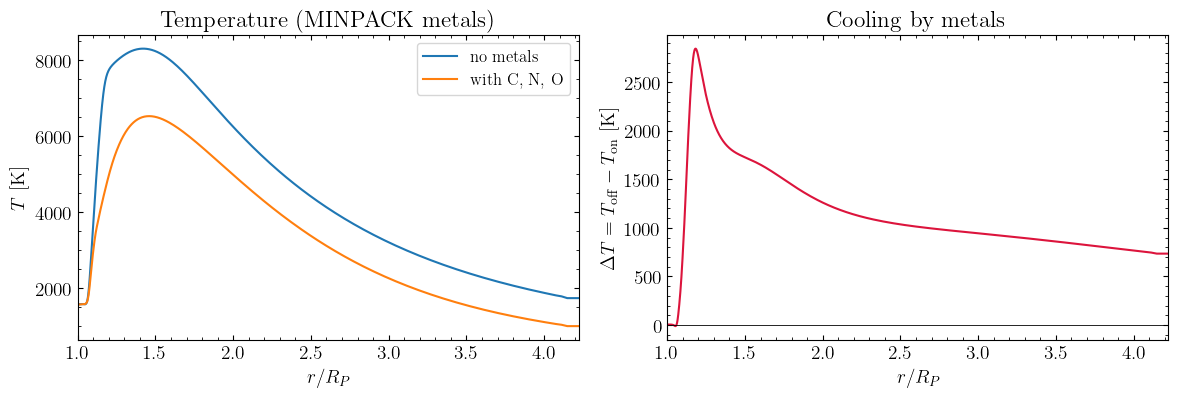

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(r, H_off['T'], label='no metals')
ax[0].plot(r, H_on['T'],  label='with C, N, O')
ax[0].set_xlabel(r'$r/R_P$'); ax[0].set_ylabel(r'$T$ [K]')
ax[0].set_title('Temperature (MINPACK metals)'); ax[0].legend(); ax[0].set_xlim(r[0], r[-1])
ax[1].plot(r, dT, color='crimson'); ax[1].axhline(0, color='k', lw=0.6)
ax[1].set_xlabel(r'$r/R_P$'); ax[1].set_ylabel(r'$\Delta T = T_{\rm off}-T_{\rm on}$ [K]')
ax[1].set_title('Cooling by metals'); ax[1].set_xlim(r[0], r[-1])
plt.tight_layout(); plt.show()

## 2. Velocity and mass-flux proxy

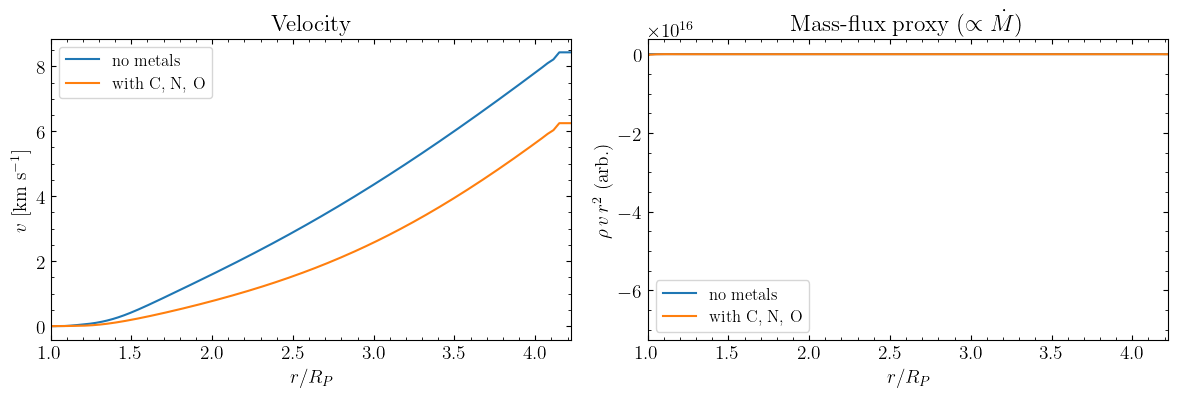

mean rho*v*r^2 ratio on/off (outer): 0.115


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(r, H_off['v']/1e5, label='no metals')
ax[0].plot(r, H_on['v']/1e5,  label='with C, N, O')
ax[0].set_xlabel(r'$r/R_P$'); ax[0].set_ylabel(r'$v$ [km s$^{-1}$]')
ax[0].set_title('Velocity'); ax[0].legend(); ax[0].set_xlim(r[0], r[-1])
mf_off = H_off['rho']*H_off['v']*r**2
mf_on  = H_on['rho'] *H_on['v'] *r**2
ax[1].plot(r, mf_off, label='no metals'); ax[1].plot(r, mf_on, label='with C, N, O')
ax[1].set_xlabel(r'$r/R_P$'); ax[1].set_ylabel(r'$\rho\,v\,r^2$ (arb.)')
ax[1].set_title(r'Mass-flux proxy ($\propto \dot M$)'); ax[1].legend(); ax[1].set_xlim(r[0], r[-1])
plt.tight_layout(); plt.show()
sel = r > 0.5*r[-1]
print(f'mean rho*v*r^2 ratio on/off (outer): {np.mean(mf_on[sel]/mf_off[sel]):.3f}')

## 3. Hydrogen ionization

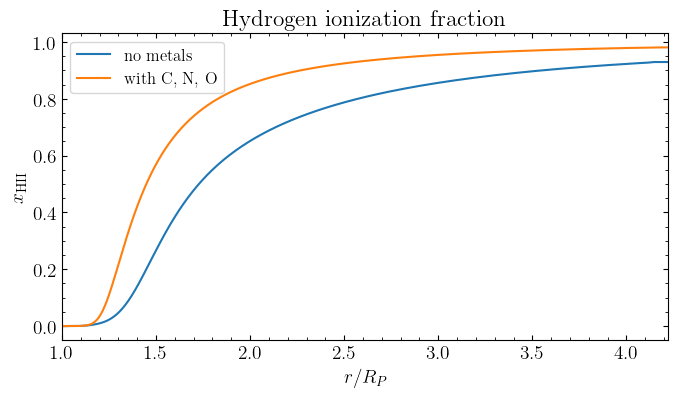

In [4]:
xHII_on  = I_on['nHII'] /(I_on['nHI'] +I_on['nHII'])
xHII_off = I_off['nHII']/(I_off['nHI']+I_off['nHII'])
fig, ax = plt.subplots(figsize=(7,4.2))
ax.plot(r, xHII_off, label='no metals'); ax.plot(r, xHII_on, label='with C, N, O')
ax.set_xlabel(r'$r/R_P$'); ax.set_ylabel(r'$x_{\rm HII}$')
ax.set_title('Hydrogen ionization fraction'); ax.legend(); ax.set_xlim(r[0], r[-1])
plt.tight_layout(); plt.show()

## 4. Metal ionization structure (from MINPACK solution)

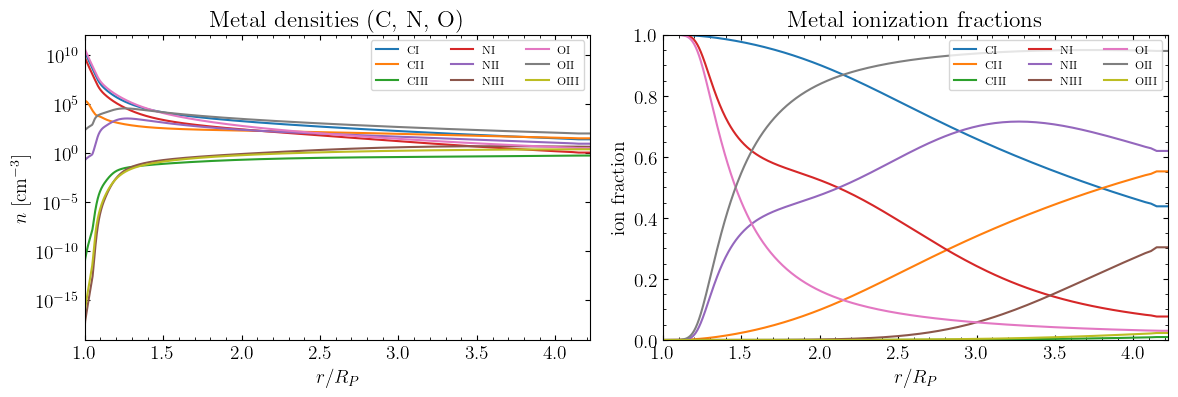

In [5]:
species = ['CI','CII','CIII','NI','NII','NIII','OI','OII','OIII']
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for nm in species:
    ax[0].semilogy(r, np.maximum(I_on[nm], 1e-30), label=nm)
ax[0].set_xlabel(r'$r/R_P$'); ax[0].set_ylabel(r'$n$ [cm$^{-3}$]')
ax[0].set_title('Metal densities (C, N, O)'); ax[0].legend(ncol=3, fontsize=8); ax[0].set_xlim(r[0], r[-1])
for grp in (['CI','CII','CIII'], ['NI','NII','NIII'], ['OI','OII','OIII']):
    tot = sum(I_on[g] for g in grp)
    for g in grp:
        ax[1].plot(r, I_on[g]/tot, label=g)
ax[1].set_xlabel(r'$r/R_P$'); ax[1].set_ylabel('ion fraction')
ax[1].set_title('Metal ionization fractions'); ax[1].legend(ncol=3, fontsize=8); ax[1].set_xlim(r[0], r[-1]); ax[1].set_ylim(0,1)
plt.tight_layout(); plt.show()

## 5. Heating / cooling rates

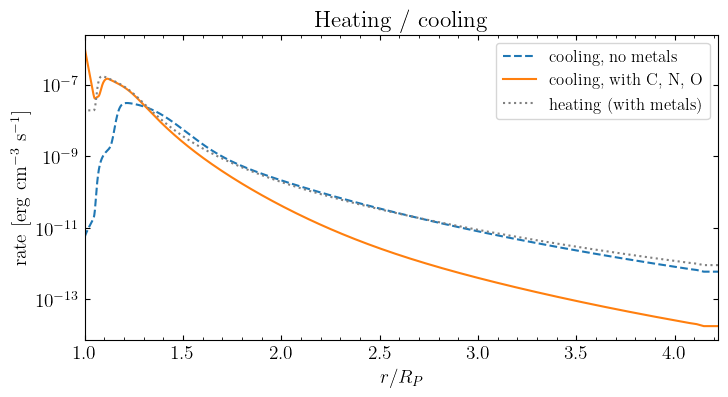

In [6]:
fig, ax = plt.subplots(figsize=(7.5,4.2))
ax.semilogy(r, H_off['cool'], '--', label='cooling, no metals')
ax.semilogy(r, H_on['cool'],        label='cooling, with C, N, O')
ax.semilogy(r, H_on['heat'], ':', color='gray', label='heating (with metals)')
ax.set_xlabel(r'$r/R_P$'); ax.set_ylabel('rate [erg cm$^{-3}$ s$^{-1}$]')
ax.set_title('Heating / cooling'); ax.legend(); ax.set_xlim(r[0], r[-1])
plt.tight_layout(); plt.show()